# 04_06_03 — GPU SB на фиксированном кэше рыночных данных

1. **Warm-up перед benchmark**, чтобы убрать JIT/NVRTC/CuPy overhead из измерений.
2. **Повторный scaling benchmark** для
   $$
   M=(512,1024,2048),\qquad batch=(128,512).
   $$
3. **Дополнительные sanity-тесты GPU-wrapper**:
   - проверка QUBO/Ising consistency;
   - проверка ориентации tabu list;
   - сравнение GPU-wrapper с точным перебором циклов на малом synthetic market graph.
4. **Real market sensitivity grid** по параметрам:
   - `n_iter = 400, 800, 1200`;
   - `n_runs = 1024, 2048, 4096`;
   - `dt = 0.35, 0.5, 0.65`;
   - `mp = 10, 25, 50, 100`.

Для real market grid есть checkpointing: после каждой конфигурации строка сохраняется в CSV, поэтому расчет можно прерывать и продолжать.

## 0. Imports, project path и проверка GPU

In [1]:
import os
import sys
import time
import json
from pathlib import Path
from itertools import permutations, product
from typing import Optional, Dict, Tuple, List

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt

# Project modules path.
for candidate in [Path.cwd(), Path('/mnt/data'), Path.cwd().parent]:
    if (candidate / 'market_graph.py').exists():
        sys.path.insert(0, str(candidate))
        print(f'Project modules path: {candidate}')
        break
else:
    print('WARNING: project .py files were not found. Put them next to this notebook.')

print('Python executable:', sys.executable)

Project modules path: c:\sb_gpu
Python executable: c:\sb_gpu\.venv\Scripts\python.exe


In [2]:
try:
    import cupy as cp
    import cupyx.scipy.sparse as cpsp
    GPU_AVAILABLE = cp.cuda.runtime.getDeviceCount() > 0
    if GPU_AVAILABLE:
        props = cp.cuda.runtime.getDeviceProperties(0)
        name = props['name'].decode() if isinstance(props['name'], bytes) else props['name']
        print('GPU:', name)
        print('CuPy:', cp.__version__)
        print('CUDA runtime:', cp.cuda.runtime.runtimeGetVersion())
    else:
        print('No CUDA GPU detected by CuPy.')
except Exception as e:
    GPU_AVAILABLE = False
    print('CuPy/GPU is not available:', repr(e))

c:\sb_gpu\.venv\Lib\site-packages\cupy\_environment.py:284: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


GPU: NVIDIA GeForce GTX 1650 SUPER
CuPy: 14.1.1
CUDA runtime: 12090


## 1. Базовые GPU/CPU SB-функции

- GPU timing измеряет только SB-core;
- начальные условия генерируются на CPU и переносятся на GPU;
- сохранена конвенция энергии
  $$
  E(s)=-\frac12 s^TJs-h^Ts.
  $$

In [4]:
def _to_dense_numpy(J):
    if sp.issparse(J):
        return J.toarray()
    return np.asarray(J)


def ising_energy_numpy(J, h, s):
    J_np = _to_dense_numpy(J).astype(np.float64, copy=False)
    h_np = np.zeros((J_np.shape[0], 1), dtype=np.float64) if h is None else np.asarray(h, dtype=np.float64).reshape(-1, 1)
    s_np = np.asarray(s, dtype=np.float64)
    Js = J_np @ s_np
    return -0.5 * np.sum(s_np * Js, axis=0) - np.sum(h_np * s_np, axis=0)


def solve_ising_cpu_batched(
    J,
    h=None,
    variant: str = 'BSB',
    n_iter: int = 100,
    dt: float = 0.65,
    batch: int = 128,
    seed: int = 42,
    xi: Optional[float] = None,
    dtype=np.float32,
):
    rng = np.random.default_rng(seed)
    J_np = _to_dense_numpy(J).astype(dtype, copy=False)
    M = J_np.shape[0]
    h_np = np.zeros((M, 1), dtype=dtype) if h is None else np.asarray(h, dtype=dtype).reshape(M, 1)

    if xi is None:
        den = np.sqrt(np.sum(J_np * J_np))
        den = den if den > 0 else 1.0
        xi_val = 0.5 * np.sqrt(M - 1) / den
    else:
        xi_val = float(xi)

    x = (0.02 * (rng.random((M, batch)) - 0.5)).astype(dtype)
    y = (0.02 * (rng.random((M, batch)) - 0.5)).astype(dtype)
    p = np.linspace(0.0, 1.0, n_iter, dtype=dtype)
    delta = dtype(1.0)
    variant = variant.upper()

    t0 = time.perf_counter()
    for t in range(n_iter):
        interaction_input = x if variant == 'BSB' else np.sign(x)
        Jx = J_np @ interaction_input
        y = y + (-(delta - p[t]) * x + xi_val * (Jx + h_np)) * dt
        x = x + dt * delta * y
        cond = np.abs(x) > 1.0
        x = np.where(cond, np.sign(x), x)
        y = np.where(cond, 0.0, y)
    elapsed_ms = (time.perf_counter() - t0) * 1000.0

    spins = np.where(x >= 0.0, 1, -1).astype(np.int8)
    energies = ising_energy_numpy(J_np, h_np, spins)
    return spins, energies, elapsed_ms, {'device': 'CPU', 'xi': xi_val}

In [5]:
def _to_gpu_matrix(J, dtype, use_sparse: bool):
    if sp.issparse(J):
        J_cpu = J.astype(np.float32 if dtype == cp.float32 else np.float64)
        if use_sparse:
            return cpsp.csr_matrix(J_cpu)
        return cp.asarray(J_cpu.toarray(), dtype=dtype)
    return cp.asarray(np.asarray(J), dtype=dtype)


def _gpu_sum_squares(J_gpu):
    if hasattr(J_gpu, 'data') and not isinstance(J_gpu, cp.ndarray):
        return cp.sum(J_gpu.data * J_gpu.data)
    return cp.sum(J_gpu * J_gpu)


def _ising_energy_gpu(J_gpu, h_gpu, s_gpu):
    Js = J_gpu.dot(s_gpu) if hasattr(J_gpu, 'dot') else J_gpu @ s_gpu
    return -0.5 * cp.sum(s_gpu * Js, axis=0) - cp.sum(h_gpu * s_gpu, axis=0)


def solve_ising_gpu_batched(
    J,
    h=None,
    variant: str = 'BSB',
    n_iter: int = 100,
    dt: float = 0.65,
    batch: int = 128,
    seed: int = 42,
    xi: Optional[float] = None,
    dtype_str: str = 'float32',
    use_sparse: bool = False,
):
    if not GPU_AVAILABLE:
        raise RuntimeError('GPU/CuPy is not available in this environment.')

    dtype = cp.float32 if dtype_str == 'float32' else cp.float64
    rng = np.random.default_rng(seed)
    J_gpu = _to_gpu_matrix(J, dtype=dtype, use_sparse=use_sparse)
    M = J.shape[0]
    h_gpu = cp.zeros((M, 1), dtype=dtype) if h is None else cp.asarray(np.asarray(h).reshape(M, 1), dtype=dtype)

    if xi is None:
        den = cp.sqrt(_gpu_sum_squares(J_gpu))
        den = cp.where(den > 0, den, cp.asarray(1.0, dtype=dtype))
        xi_gpu = cp.asarray(0.5, dtype=dtype) * cp.sqrt(cp.asarray(M - 1, dtype=dtype)) / den
    else:
        xi_gpu = cp.asarray(float(xi), dtype=dtype)

    x_cpu = (0.02 * (rng.random((M, batch)) - 0.5)).astype(np.float32 if dtype_str == 'float32' else np.float64)
    y_cpu = (0.02 * (rng.random((M, batch)) - 0.5)).astype(np.float32 if dtype_str == 'float32' else np.float64)
    x = cp.asarray(x_cpu, dtype=dtype)
    y = cp.asarray(y_cpu, dtype=dtype)

    p = cp.linspace(0.0, 1.0, n_iter, dtype=dtype)
    delta = cp.asarray(1.0, dtype=dtype)
    variant = variant.upper()

    cp.cuda.Stream.null.synchronize()
    start = cp.cuda.Event()
    end = cp.cuda.Event()
    start.record()

    for t in range(n_iter):
        interaction_input = x if variant == 'BSB' else cp.sign(x)
        Jx = J_gpu.dot(interaction_input) if hasattr(J_gpu, 'dot') else J_gpu @ interaction_input
        y = y + (-(delta - p[t]) * x + xi_gpu * (Jx + h_gpu)) * dt
        x = x + dt * delta * y
        cond = cp.abs(x) > 1.0
        x = cp.where(cond, cp.sign(x), x)
        y = cp.where(cond, 0.0, y)

    spins_gpu = cp.where(x >= 0.0, 1, -1).astype(cp.int8)
    energies_gpu = _ising_energy_gpu(J_gpu, h_gpu, spins_gpu)

    end.record()
    end.synchronize()
    elapsed_ms = cp.cuda.get_elapsed_time(start, end)

    spins = cp.asnumpy(spins_gpu)
    energies = cp.asnumpy(energies_gpu)
    xi_val = float(cp.asnumpy(xi_gpu))
    return spins, energies, elapsed_ms, {
        'device': 'GPU',
        'xi': xi_val,
        'dtype': dtype_str,
        'use_sparse': use_sparse,
        'batch': batch,
        'n_iter': n_iter,
    }

In [6]:
def make_random_ising(M: int, density: float = 1.0, seed: int = 0, weight_scale: float = 1.0):
    rng = np.random.default_rng(seed)
    if density >= 1.0:
        A = rng.choice([-1.0, 1.0], size=(M, M)).astype(np.float32) * weight_scale
        J = np.triu(A, 1)
        J = J + J.T
        h = np.zeros((M, 1), dtype=np.float32)
        return J.astype(np.float32), h

    rows, cols, data = [], [], []
    for i in range(M):
        js = np.where(rng.random(M - i - 1) < density)[0] + i + 1
        vals = rng.choice([-1.0, 1.0], size=len(js)).astype(np.float32) * weight_scale
        rows.extend([i] * len(js))
        cols.extend(js.tolist())
        data.extend(vals.tolist())
    U = sp.coo_matrix((data, (rows, cols)), shape=(M, M), dtype=np.float32).tocsr()
    J = (U + U.T).tocsr()
    h = np.zeros((M, 1), dtype=np.float32)
    return J, h


def summarize_energies(energies):
    energies = np.asarray(energies)
    return {
        'best_energy': float(np.min(energies)),
        'mean_energy': float(np.mean(energies)),
        'std_energy': float(np.std(energies)),
    }


def gpu_warmup(dtype_str='float32'):
    if not GPU_AVAILABLE:
        print('GPU warm-up skipped: no GPU')
        return
    Jw, hw = make_random_ising(64, seed=123)
    _ = solve_ising_gpu_batched(Jw, hw, variant='BSB', n_iter=5, batch=8, seed=1, dtype_str=dtype_str)
    cp.cuda.Stream.null.synchronize()
    print('GPU warm-up done')

## 2. Warm-up и scaling benchmark

In [7]:
gpu_warmup()

GPU warm-up done


In [8]:
def benchmark_cpu_gpu_scaling_warm(
    M_values=(512, 1024, 2048),
    batch_values=(128, 512),
    n_iter: int = 100,
    variant: str = 'BSB',
    seed: int = 123,
    density: float = 1.0,
    repeat_gpu: int = 2,
):
    records = []
    for M in M_values:
        J, h = make_random_ising(M, density=density, seed=seed + M)
        for batch in batch_values:
            print(f'Benchmark M={M}, batch={batch}')

            # CPU baseline
            try:
                _, e_cpu, ms_cpu, _ = solve_ising_cpu_batched(
                    J, h, variant=variant, n_iter=n_iter, batch=batch, seed=seed
                )
                rec = {
                    'device': 'CPU', 'M': M, 'batch': batch, 'n_iter': n_iter,
                    'elapsed_ms': ms_cpu, 'ms_per_run': ms_cpu / batch,
                }
                rec.update(summarize_energies(e_cpu))
                records.append(rec)
            except Exception as ex:
                records.append({'device': 'CPU', 'M': M, 'batch': batch, 'n_iter': n_iter,
                                'elapsed_ms': np.nan, 'ms_per_run': np.nan, 'error': repr(ex)})

            # GPU: run more than once and use the last/median after warm-up.
            if GPU_AVAILABLE:
                gpu_runs = []
                e_gpu_last = None
                try:
                    # shape-specific warm-up
                    _ = solve_ising_gpu_batched(J, h, variant=variant, n_iter=3, batch=min(batch, 32), seed=seed)
                    for rep in range(repeat_gpu):
                        _, e_gpu, ms_gpu, _ = solve_ising_gpu_batched(
                            J, h, variant=variant, n_iter=n_iter, batch=batch, seed=seed + rep,
                            dtype_str='float32', use_sparse=(density < 1.0)
                        )
                        gpu_runs.append(ms_gpu)
                        e_gpu_last = e_gpu
                    ms_gpu_robust = float(np.median(gpu_runs))
                    rec = {
                        'device': 'GPU', 'M': M, 'batch': batch, 'n_iter': n_iter,
                        'elapsed_ms': ms_gpu_robust, 'ms_per_run': ms_gpu_robust / batch,
                        'gpu_repeats': repeat_gpu,
                    }
                    rec.update(summarize_energies(e_gpu_last))
                    records.append(rec)
                except Exception as ex:
                    records.append({'device': 'GPU', 'M': M, 'batch': batch, 'n_iter': n_iter,
                                    'elapsed_ms': np.nan, 'ms_per_run': np.nan, 'error': repr(ex)})
    return pd.DataFrame(records)

In [9]:
scaling_warm_df = benchmark_cpu_gpu_scaling_warm(
    M_values=(512, 1024, 2048),
    batch_values=(128, 512),
    n_iter=100,
    variant='BSB',
    repeat_gpu=2,
)
scaling_warm_df.to_csv('gpu_sb_scaling_benchmark_warm.csv', index=False)
scaling_warm_df

Benchmark M=512, batch=128
Benchmark M=512, batch=512
Benchmark M=1024, batch=128
Benchmark M=1024, batch=512
Benchmark M=2048, batch=128
Benchmark M=2048, batch=512


,device,M,batch,n_iter,elapsed_ms,ms_per_run,best_energy,mean_energy,std_energy,gpu_repeats
0,CPU,512,128,100,324.355200,2.534025,-8790.0,-8605.937500,106.605270,NaN
1,GPU,512,128,100,112.993404,0.882761,-8788.0,-8589.187500,97.508461,2.0
2,CPU,512,512,100,1582.911000,3.091623,-8790.0,-8610.410156,91.069748,NaN
3,GPU,512,512,100,50.228529,0.098103,-8790.0,-8596.054688,98.410950,2.0
4,CPU,1024,128,100,1270.952100,9.929313,-24494.0,-24181.656250,187.915059,NaN
5,GPU,1024,128,100,47.626257,0.372080,-24558.0,-24172.250000,173.618118,2.0
6,CPU,1024,512,100,3608.299600,7.047460,-24624.0,-24182.335938,161.462543,NaN
7,GPU,1024,512,100,168.084690,0.328290,-24576.0,-24186.890625,168.147461,2.0
8,CPU,2048,128,100,3141.509100,24.543040,-69510.0,-68525.875000,364.691029,NaN
9,GPU,2048,128,100,57.031376,0.445558,-69872.0,-68533.562500,401.774841,2.0


In [10]:
pivot = scaling_warm_df.pivot_table(index=['M', 'batch'], columns='device', values='ms_per_run').reset_index()
if {'CPU', 'GPU'}.issubset(set(pivot.columns)):
    pivot['speedup_CPU_over_GPU'] = pivot['CPU'] / pivot['GPU']
    display(pivot)
    pivot.to_csv('gpu_sb_scaling_speedup_warm.csv', index=False)

device,M,batch,CPU,GPU,speedup_CPU_over_GPU
0,512,128,2.534025,0.882761,2.870568
1,512,512,3.091623,0.098103,31.514182
2,1024,128,9.929313,0.372080,26.685954
3,1024,512,7.047460,0.328290,21.467152
4,2048,128,24.543040,0.445558,55.083874
5,2048,512,18.353211,0.522945,35.095880


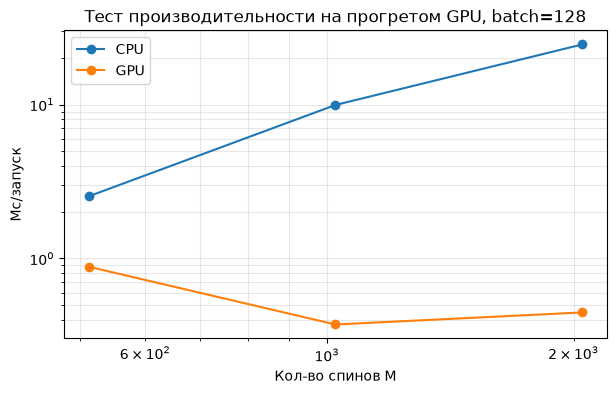

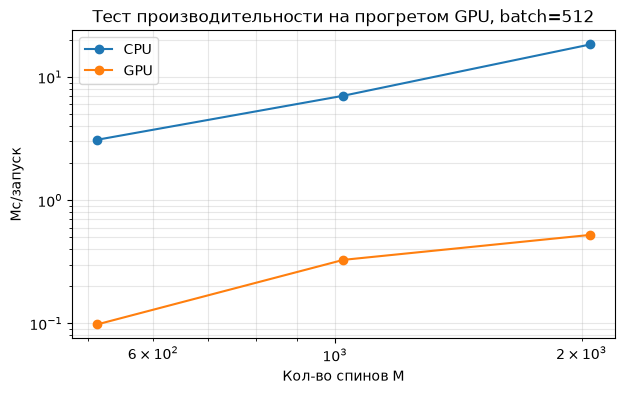

In [12]:
plot_df = scaling_warm_df.dropna(subset=['ms_per_run']).copy()
for batch in sorted(plot_df['batch'].unique()):
    plt.figure(figsize=(7, 4))
    sub = plot_df[plot_df['batch'] == batch]
    for device in sorted(sub['device'].unique()):
        d = sub[sub['device'] == device].sort_values('M')
        plt.plot(d['M'], d['ms_per_run'], marker='o', label=device)
    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Кол-во спинов M')
    plt.ylabel('Мс/запуск')
    plt.title(f'Тест производительности на прогретом GPU, batch={batch}')
    plt.grid(True, which='both', alpha=0.3)
    plt.legend()
    plt.show()

## 3. Дополнительные тесты корректности GPU-wrapper

Проверяем не только SB-speed, но и то, что обвязка QUBO pairs trading не нарушает индексацию, tabu и декодирование.

In [13]:
from market_graph import build_market_weights
from qubo_cycle import build_cycle_qubo
from ising_mapping import qubo_to_ising
from pair_search import CycleSolution, TabuList, verify_single_dummy_cycle, extract_pair_and_weight


def _decode_edges_from_z(z: np.ndarray, var_map):
    z = np.asarray(z).astype(int).reshape(-1)
    return [var_map.u2e[u] for u, bit in enumerate(z) if bit == 1]


def qubo_energy(lin, quad, z):
    z = np.asarray(z, dtype=float).reshape(-1)
    E = float(np.dot(lin, z))
    for (i, j), q in quad.items():
        E += float(q) * z[i] * z[j]
    return E


def cycle_to_z(cycle_nodes, var_map):
    z = np.zeros(len(var_map.edges), dtype=int)
    for a, b in zip(cycle_nodes[:-1], cycle_nodes[1:]):
        z[var_map.e2u[(a, b)]] = 1
    return z

In [14]:
def test_qubo_ising_consistency(seed=0):
    rng = np.random.default_rng(seed)
    N = 4
    w = rng.normal(scale=0.01, size=(N+1, N+1))
    np.fill_diagonal(w, 0.0)
    w[0, :] = 0.0
    w[:, 0] = 0.0

    lin, quad, var_map = build_cycle_qubo(w, mc=1.0, mp=10.0)
    J, h, const = qubo_to_ising(lin, quad)
    J_dense = J.toarray()

    for _ in range(100):
        z = rng.integers(0, 2, size=len(lin))
        s = (2*z - 1).reshape(-1, 1)
        E_qubo = qubo_energy(lin, quad, z)
        E_ising = float(const + ising_energy_numpy(J_dense, h, s)[0])
        if not np.isclose(E_qubo, E_ising, atol=1e-7):
            raise AssertionError((E_qubo, E_ising))
    print('OK: QUBO -> Ising consistency')


def test_tabu_orientation():
    N = 3
    w = np.zeros((N+1, N+1), dtype=float)
    tabu = TabuList(N)
    tabu.forbid(short=1, long=2)
    lin, quad, var_map = build_cycle_qubo(w, tabu=tabu.T, mc=1.0, mp=10.0)

    forbidden_cycle = [0, 1, 2, 0]   # short=1, long=2
    reverse_cycle = [0, 2, 1, 0]     # short=2, long=1
    other_cycle = [0, 1, 3, 0]

    E_forbidden = qubo_energy(lin, quad, cycle_to_z(forbidden_cycle, var_map))
    E_reverse = qubo_energy(lin, quad, cycle_to_z(reverse_cycle, var_map))
    E_other = qubo_energy(lin, quad, cycle_to_z(other_cycle, var_map))

    print('E forbidden:', E_forbidden)
    print('E reverse  :', E_reverse)
    print('E other    :', E_other)

    assert E_forbidden > E_reverse
    assert E_forbidden > E_other
    print('OK: tabu orientation')


test_qubo_ising_consistency()
test_tabu_orientation()

OK: QUBO -> Ising consistency
E forbidden: 10.0
E reverse  : 0.0
E other    : 0.0
OK: tabu orientation


In [15]:
def solve_best_cycle_with_gpu(
    w: np.ndarray,
    tabu: Optional[TabuList] = None,
    sb_variant: str = 'BSB',
    n_runs: int = 512,
    n_iter: int = 300,
    dt: float = 0.65,
    mc: float = 1.0,
    mp: Optional[float] = None,
    seed: int = 42,
    dtype_str: str = 'float32',
    use_sparse: bool = False,
):
    t_total0 = time.perf_counter()
    w = np.asarray(w, dtype=float)
    N = w.shape[0] - 1
    if tabu is None:
        tabu = TabuList(N)

    # tabu.T is the matrix attribute of TabuList, not numpy transpose.
    tabu_matrix = tabu.T
    lin, quad, var_map = build_cycle_qubo(w, tabu=tabu_matrix, mc=mc, mp=mp)
    J, h, const = qubo_to_ising(lin, quad)

    spins, energies, elapsed_gpu_core_ms, info = solve_ising_gpu_batched(
        J, h=h, variant=sb_variant, n_iter=n_iter, dt=dt, batch=n_runs,
        seed=seed, dtype_str=dtype_str, use_sparse=use_sparse,
    )

    best = None
    best_valid_ising_energy = None
    valid_count = 0
    z_batch = ((spins + 1) // 2).astype(int)

    for r in range(n_runs):
        z = z_batch[:, r]
        selected_edges = _decode_edges_from_z(z, var_map)
        ok, cycle = verify_single_dummy_cycle(selected_edges, N)
        if not ok or cycle is None:
            continue
        valid_count += 1
        short, long, path_nodes, path_weight = extract_pair_and_weight(cycle, w)
        sol = CycleSolution(
            ok=True,
            cycle_nodes=cycle,
            short_node=short,
            long_node=long,
            path_nodes=path_nodes,
            path_weight=float(path_weight),
            edges_selected=selected_edges,
        )
        if best is None or sol.path_weight < best.path_weight:
            best = sol
            best_valid_ising_energy = float(energies[r])

    elapsed_total_ms = 1000.0 * (time.perf_counter() - t_total0)
    stats = {
        'elapsed_gpu_core_ms': elapsed_gpu_core_ms,
        'elapsed_total_ms': elapsed_total_ms,
        'ms_per_run_gpu_core': elapsed_gpu_core_ms / n_runs,
        'ms_per_run_total': elapsed_total_ms / n_runs,
        'n_runs': n_runs,
        'n_iter': n_iter,
        'valid_count': valid_count,
        'valid_rate': valid_count / n_runs,
        'best_valid_path_weight': None if best is None else best.path_weight,
        'best_valid_ising_energy': best_valid_ising_energy,
        'best_any_ising_energy': float(np.min(energies)),
        'mean_any_ising_energy': float(np.mean(energies)),
        'M_ising': J.shape[0],
        **info,
    }
    return best, stats


def find_multiple_pairs_gpu(
    w: np.ndarray,
    threshold: float,
    max_pairs: int = 5,
    sb_variant: str = 'BSB',
    n_runs_per_pair: int = 512,
    n_iter: int = 300,
    dt: float = 0.65,
    mc: float = 1.0,
    mp: Optional[float] = None,
    seed: int = 42,
    debug: bool = True,
    dtype_str: str = 'float32',
    use_sparse: bool = False,
):
    w = np.asarray(w, dtype=float)
    N = w.shape[0] - 1
    tabu = TabuList(N)
    results = []
    stats_rows = []

    for k in range(max_pairs):
        sol, stats = solve_best_cycle_with_gpu(
            w=w, tabu=tabu, sb_variant=sb_variant,
            n_runs=n_runs_per_pair, n_iter=n_iter, dt=dt,
            mc=mc, mp=mp, seed=seed + 1000*k,
            dtype_str=dtype_str, use_sparse=use_sparse,
        )
        stats['k'] = k
        stats_rows.append(stats)

        if sol is None:
            if debug:
                print(f'[k={k}] no valid dummy-cycle found; valid_rate={stats["valid_rate"]:.3f}')
            break

        if debug:
            print(f'[k={k}] best weight={sol.path_weight:.8f}, path={sol.path_nodes}, '
                  f'valid_rate={stats["valid_rate"]:.3f}, core={stats["elapsed_gpu_core_ms"]:.3f} ms, total={stats["elapsed_total_ms"]:.3f} ms')

        if sol.path_weight >= threshold:
            if debug:
                print(f'[k={k}] stop: weight {sol.path_weight:.8f} >= threshold {threshold:.8f}')
            break

        results.append(sol)
        tabu.forbid(short=sol.short_node, long=sol.long_node)

    return results, pd.DataFrame(stats_rows)

In [ ]:
def exact_best_dummy_cycle(w: np.ndarray, tabu_pairs=None):
    """
    Exact search over all simple dummy cycles [0, short, ..., long, 0].
    Only for small N, e.g. N <= 8.
    """
    w = np.asarray(w, dtype=float)
    N = w.shape[0] - 1
    nodes = list(range(1, N+1))
    tabu_pairs = set(tabu_pairs or [])  # set of (short, long)
    best = None

    for L in range(2, N+1):
        for path in permutations(nodes, L):
            short, long = path[0], path[-1]
            if (short, long) in tabu_pairs:
                continue
            weight = 0.0
            for a, b in zip(path[:-1], path[1:]):
                weight += float(w[a, b])
            cycle = [0] + list(path) + [0]
            if best is None or weight < best['path_weight']:
                best = {
                    'cycle_nodes': cycle,
                    'path_nodes': list(path),
                    'short_node': short,
                    'long_node': long,
                    'path_weight': weight,
                }
    return best


def make_synthetic_market(N: int = 6, seed: int = 42):
    rng = np.random.default_rng(seed)
    mid = 1.0 + 0.04 * rng.normal(size=N)
    spread = 0.001 + 0.002 * rng.random(N)
    bid = mid - spread/2
    ask = mid + spread/2
    A = rng.random((N, N))
    sim = (A + A.T) / 2
    np.fill_diagonal(sim, 0.0)

    if N >= 4:
        sim[0, 1] = sim[1, 0] = 0.98
        ask[1] = min(ask[1], bid[0] - 0.015)
        sim[2, 3] = sim[3, 2] = 0.95
        ask[3] = min(ask[3], bid[2] - 0.012)
    return ask, bid, sim, build_market_weights(ask, bid, sim)

ask_t, bid_t, sim_t, w_t = make_synthetic_market(N=6, seed=11)
exact = exact_best_dummy_cycle(w_t)
print('Exact best:', exact)

if GPU_AVAILABLE:
    gpu_sol, gpu_stats = solve_best_cycle_with_gpu(
        w_t, sb_variant='BSB', n_runs=4096, n_iter=800, dt=0.5, mp=50.0, seed=77
    )
    print('GPU sol:', gpu_sol)
    print('GPU stats:', gpu_stats)
    if gpu_sol is not None:
        print('Exact weight:', exact['path_weight'])
        print('GPU weight  :', gpu_sol.path_weight)
        print('Difference  :', gpu_sol.path_weight - exact['path_weight'])

Exact best: {'cycle_nodes': [0, 3, 4, 2, 1, 5, 6, 0], 'path_nodes': [3, 4, 2, 1, 5, 6], 'short_node': 3, 'long_node': 6, 'path_weight': -0.12243920779883138}
GPU sol: CycleSolution(ok=True, cycle_nodes=[0, 3, 4, 2, 1, 5, 6, 0], short_node=3, long_node=6, path_nodes=[3, 4, 2, 1, 5, 6], path_weight=-0.12243920779883138, edges_selected=[(0, 3), (1, 5), (2, 1), (3, 4), (4, 2), (5, 6), (6, 0)])
GPU stats: {'elapsed_gpu_core_ms': 377.7132568359375, 'elapsed_total_ms': 468.5886000006576, 'ms_per_run_gpu_core': 0.0922151505947113, 'ms_per_run_total': 0.11440151367203555, 'n_runs': 4096, 'n_iter': 800, 'valid_count': 2115, 'valid_rate': 0.516357421875, 'best_valid_path_weight': -0.12243920779883138, 'best_valid_ising_energy': -3937.5390625, 'best_any_ising_energy': -3937.5390625, 'mean_any_ising_energy': -3937.43896484375, 'M_ising': 42, 'device': 'GPU', 'xi': 0.0033521223813295364, 'dtype': 'float32', 'use_sparse': False, 'batch': 4096}
Exact weight: -0.12243920779883138
GPU weight  : -0.12243

## 4. Real market graph: фиксированный кэш JSON

В этой версии тетрадки рыночный граф строится **только из сохраненных JSON-файлов**:

- `book_tickers.json`;
- `klines_<SYMBOL>_1h_240.json`.

Live-запросы к Binance не используются. Это нужно, чтобы CPU- и GPU-реализации решали одну и ту же QUBO-задачу, а не разные рыночные снимки.

В загруженном кэше последним днем является `20260609`. Для similarity используются последние пять полных дней до него:

$$
20260604,\ 20260605,\ 20260606,\ 20260607,\ 20260608.
$$

In [ ]:
from dtw_similarity import build_daily_sequences_from_hourly_klines, dtw_distance

SYMBOLS = [
    'BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT',
    'ADAUSDT', 'DOGEUSDT', 'AVAXUSDT', 'LINKUSDT', 'DOTUSDT',
    'TRXUSDT', 'LTCUSDT', 'BCHUSDT', 'ATOMUSDT', 'ETCUSDT',
]

SNAPSHOT_DAY = 20260609
DAYS_BACK = 5


def _utc_day_from_kline(k):
    from datetime import datetime, timezone
    ts_ms = int(k[0])
    dt = datetime.fromtimestamp(ts_ms / 1000.0, tz=timezone.utc)
    return int(dt.strftime("%Y%m%d"))


def load_book_tickers_cached(cache_dir: Path, symbols):
    path = cache_dir / 'book_tickers.json'
    obj = json.loads(path.read_text(encoding='utf-8'))

    out = {}
    if isinstance(obj, list):
        for item in obj:
            sym = item['symbol']
            if sym in symbols:
                bid = float(item.get('bidPrice', item.get('bid')))
                ask = float(item.get('askPrice', item.get('ask')))
                out[sym] = (bid, ask)
    elif isinstance(obj, dict):
        for sym in symbols:
            v = obj[sym]
            if isinstance(v, dict):
                bid = float(v.get('bidPrice', v.get('bid')))
                ask = float(v.get('askPrice', v.get('ask')))
            else:
                bid = float(v[0])
                ask = float(v[1])
            out[sym] = (bid, ask)

    missing = [s for s in symbols if s not in out]
    if missing:
        raise ValueError(f'Missing symbols in book_tickers cache: {missing}')

    return out


def load_klines_cached(cache_dir: Path, symbols):
    out = {}
    for sym in symbols:
        path = cache_dir / f'klines_{sym}_1h_240.json'
        if not path.exists():
            raise FileNotFoundError(f'Missing klines file: {path}')
        out[sym] = json.loads(path.read_text(encoding='utf-8'))
    return out


def get_base_open_for_day(klines_1h, day: int):
    rows = [k for k in klines_1h if _utc_day_from_kline(k) == day]
    if not rows:
        raise ValueError(f'No klines for day {day}')
    rows = sorted(rows, key=lambda k: int(k[0]))
    return float(rows[0][1])


def compute_similarity_matrix_for_snapshot(symbols, daily_seq, snapshot_day: int, days_back: int = 5):
    """
    Similarity считаем только по дням ДО snapshot_day.
    Это фиксирует эксперимент и делает CPU/GPU сравнение корректным.
    """
    common_days = None
    for sym in symbols:
        days = set(daily_seq[sym].keys())
        common_days = days if common_days is None else common_days & days

    days_sorted = sorted(d for d in common_days if d < snapshot_day)
    used_days = days_sorted[-days_back:]

    if len(used_days) == 0:
        raise ValueError('No historical days before snapshot_day for similarity calculation.')

    N = len(symbols)
    D = np.zeros((N, N), dtype=float)

    for i in range(N):
        for j in range(i + 1, N):
            ds = []
            for day in used_days:
                a = daily_seq[symbols[i]][day]
                b = daily_seq[symbols[j]][day]
                ds.append(dtw_distance(a, b))
            D[i, j] = D[j, i] = float(np.mean(ds))

    off_diag = D[~np.eye(N, dtype=bool)]
    dmin = float(np.min(off_diag))
    dmax = float(np.max(off_diag))

    if dmax <= dmin + 1e-12:
        S = np.ones((N, N), dtype=float)
    else:
        S = 1.0 - (D - dmin) / (dmax - dmin)
        S = np.clip(S, 0.0, 1.0)

    np.fill_diagonal(S, 0.0)
    return S, used_days


def build_market_graph_from_cached_json(
    cache_dir: Path | None = None,
    symbols=SYMBOLS,
    snapshot_day: int = SNAPSHOT_DAY,
    days_back: int = DAYS_BACK,
):

    print('Cache dir:', cache_dir)

    book = load_book_tickers_cached(cache_dir, symbols)
    klines_by_symbol = load_klines_cached(cache_dir, symbols)

    daily_seq = {
        sym: build_daily_sequences_from_hourly_klines(klines_by_symbol[sym])
        for sym in symbols
    }

    S, used_days = compute_similarity_matrix_for_snapshot(
        symbols=symbols,
        daily_seq=daily_seq,
        snapshot_day=snapshot_day,
        days_back=days_back,
    )

    bid_raw = np.array([book[s][0] for s in symbols], dtype=float)
    ask_raw = np.array([book[s][1] for s in symbols], dtype=float)

    base_open = np.array([
        get_base_open_for_day(klines_by_symbol[sym], snapshot_day)
        for sym in symbols
    ], dtype=float)

    bid = bid_raw / base_open
    ask = ask_raw / base_open

    w = build_market_weights(ask=ask, bid=bid, sim=S)

    meta = {
        'symbols': list(symbols),
        'snapshot_day': int(snapshot_day),
        'used_days': [int(x) for x in used_days],
        'bid_raw': bid_raw.tolist(),
        'ask_raw': ask_raw.tolist(),
        'base_open': base_open.tolist(),
        'bid_norm': bid.tolist(),
        'ask_norm': ask.tolist(),
        'similarity': S.tolist(),
    }

    return w, meta


def load_or_build_real_market_graph(force_rebuild=False):
    w_path = Path(f'real_market_w_cached_{SNAPSHOT_DAY}.npy')
    meta_path = Path(f'real_market_meta_cached_{SNAPSHOT_DAY}.json')

    if (not force_rebuild) and w_path.exists() and meta_path.exists():
        print('Loading cached processed market graph')
        w = np.load(w_path)
        meta = json.loads(meta_path.read_text(encoding='utf-8'))
        return w, meta

    w, meta = build_market_graph_from_cached_json(cache_dir="binance_data_cached_20260609")
    np.save(w_path, w)
    meta_path.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding='utf-8')
    print(f'Saved {w_path} and {meta_path}')
    return w, meta

In [ ]:
w_real, meta_real = load_or_build_real_market_graph(force_rebuild=False)

print('snapshot_day:', meta_real['snapshot_day'])
print('used_days:', meta_real['used_days'])
print('symbols:', meta_real['symbols'])
print('w_real shape:', w_real.shape)

neg_edges = w_real[1:, 1:][w_real[1:, 1:] < 0]
threshold_real = float(np.quantile(neg_edges, 0.10)) if neg_edges.size else -1e-4

print('Negative edge count:', neg_edges.size)
print('Min negative edge:', float(np.min(neg_edges)) if neg_edges.size else None)
print('Fixed threshold for sensitivity:', threshold_real)

rows = []
symbols = meta_real['symbols']
S = np.asarray(meta_real['similarity'])
for i in range(1, len(symbols) + 1):
    for j in range(1, len(symbols) + 1):
        if i != j and w_real[i, j] < 0:
            rows.append({
                'short_symbol': symbols[i - 1],
                'long_symbol': symbols[j - 1],
                'weight': float(w_real[i, j]),
                'similarity': float(S[i - 1, j - 1]),
            })

top_negative_edges_df = pd.DataFrame(rows).sort_values('weight')
top_negative_edges_df.to_csv(f'cached_top_negative_edges_{SNAPSHOT_DAY}.csv', index=False)
display(top_negative_edges_df.head(20))

Loading cached processed market graph
snapshot_day: 20260609
used_days: [20260604, 20260605, 20260606, 20260607, 20260608]
symbols: ['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'SOLUSDT', 'XRPUSDT', 'ADAUSDT', 'DOGEUSDT', 'AVAXUSDT', 'LINKUSDT', 'DOTUSDT', 'TRXUSDT', 'LTCUSDT', 'BCHUSDT', 'ATOMUSDT', 'ETCUSDT']
w_real shape: (16, 16)
Negative edge count: 100
Min negative edge: -0.02664271630185152
Fixed threshold for sensitivity: -0.018998980097758696


,short_symbol,long_symbol,weight,similarity
68,LTCUSDT,XRPUSDT,-0.026643,0.891797
67,LTCUSDT,SOLUSDT,-0.026641,0.893554
65,LTCUSDT,ETHUSDT,-0.025010,0.805923
80,ATOMUSDT,SOLUSDT,-0.024776,0.903604
64,LTCUSDT,BTCUSDT,-0.024708,0.908483
81,ATOMUSDT,XRPUSDT,-0.024296,0.884130
78,ATOMUSDT,ETHUSDT,-0.024273,0.847594
70,LTCUSDT,DOGEUSDT,-0.019704,0.858106
72,LTCUSDT,LINKUSDT,-0.019561,0.793834
85,ATOMUSDT,LINKUSDT,-0.019093,0.858277


## 5. Real market sensitivity grid

In [ ]:
N_ITER_GRID = [300, 500, 700, 900, 1100]
N_RUNS_GRID = [100, 300, 500, 1024, 2048, 4096]
DT_GRID = [0.1, 0.2, 0.35, 0.50, 0.65]
MP_GRID = [0.1, 0.25, 0.37061, 0.5, 100.0]

MAX_PAIRS_FOR_GRID = 3

grid_configs = list(product(N_ITER_GRID, N_RUNS_GRID, DT_GRID, MP_GRID))

print('Number of configs:', len(grid_configs))
print(grid_configs[:10])

Number of configs: 750
[(300, 100, 0.1, 0.1), (300, 100, 0.1, 0.25), (300, 100, 0.1, 0.37061), (300, 100, 0.1, 0.5), (300, 100, 0.1, 100.0), (300, 100, 0.2, 0.1), (300, 100, 0.2, 0.25), (300, 100, 0.2, 0.37061), (300, 100, 0.2, 0.5), (300, 100, 0.2, 100.0)]


In [23]:
def run_real_market_sensitivity_grid(
    w_real,
    threshold_real: float,
    grid_configs,
    out_csv: str = f'gpu_sb_real_market_sensitivity_grid_cached_{SNAPSHOT_DAY}.csv',
    max_pairs: int = 3,
    seed: int = 2026,
):
    out_path = Path(out_csv)
    if out_path.exists():
        df_done = pd.read_csv(out_path)
        done_keys = set(tuple(x) for x in df_done[['n_iter', 'n_runs', 'dt', 'mp']].itertuples(index=False, name=None))
        rows = df_done.to_dict('records')
        print(f'Loaded checkpoint with {len(rows)} rows')
    else:
        done_keys = set()
        rows = []

    total = len(grid_configs)
    for idx, (n_iter, n_runs, dt, mp) in enumerate(grid_configs, start=1):
        key = (n_iter, n_runs, dt, mp)
        if key in done_keys:
            print(f'[{idx}/{total}] skip existing {key}')
            continue

        print(f'[{idx}/{total}] n_iter={n_iter}, n_runs={n_runs}, dt={dt}, mp={mp}')
        t0 = time.perf_counter()
        try:
            pairs, stats_df = find_multiple_pairs_gpu(
                w=w_real,
                threshold=threshold_real,
                max_pairs=max_pairs,
                sb_variant='BSB',
                n_runs_per_pair=n_runs,
                n_iter=n_iter,
                dt=dt,
                mp=mp,
                seed=seed,
                debug=False,
            )
            elapsed_grid_ms = 1000.0 * (time.perf_counter() - t0)

            row = {
                'n_iter': n_iter,
                'n_runs': n_runs,
                'dt': dt,
                'mp': mp,
                'threshold': threshold_real,
                'max_pairs': max_pairs,
                'n_pairs_found': len(pairs),
                'elapsed_grid_ms': elapsed_grid_ms,
                'mean_valid_rate': float(stats_df['valid_rate'].mean()) if len(stats_df) else np.nan,
                'max_valid_rate': float(stats_df['valid_rate'].max()) if len(stats_df) else np.nan,
                'min_valid_rate': float(stats_df['valid_rate'].min()) if len(stats_df) else np.nan,
                'mean_gpu_core_ms': float(stats_df['elapsed_gpu_core_ms'].mean()) if len(stats_df) else np.nan,
                'mean_total_ms': float(stats_df['elapsed_total_ms'].mean()) if len(stats_df) else np.nan,
                'sum_gpu_core_ms': float(stats_df['elapsed_gpu_core_ms'].sum()) if len(stats_df) else np.nan,
                'sum_total_ms': float(stats_df['elapsed_total_ms'].sum()) if len(stats_df) else np.nan,
                'error': None,
            }

            if len(pairs) > 0:
                p0 = pairs[0]
                row.update({
                    'first_short_node': p0.short_node,
                    'first_long_node': p0.long_node,
                    'first_short_symbol': meta_real['symbols'][p0.short_node - 1],
                    'first_long_symbol': meta_real['symbols'][p0.long_node - 1],
                    'first_path_weight': p0.path_weight,
                    'first_path_nodes': str(p0.path_nodes),
                    'first_path_symbols': str([meta_real['symbols'][i-1] for i in p0.path_nodes]),
                })
            else:
                row.update({
                    'first_short_node': None,
                    'first_long_node': None,
                    'first_short_symbol': None,
                    'first_long_symbol': None,
                    'first_path_weight': None,
                    'first_path_nodes': None,
                    'first_path_symbols': None,
                })

        except Exception as ex:
            row = {
                'n_iter': n_iter,
                'n_runs': n_runs,
                'dt': dt,
                'mp': mp,
                'threshold': threshold_real,
                'max_pairs': max_pairs,
                'n_pairs_found': np.nan,
                'elapsed_grid_ms': np.nan,
                'mean_valid_rate': np.nan,
                'max_valid_rate': np.nan,
                'min_valid_rate': np.nan,
                'mean_gpu_core_ms': np.nan,
                'mean_total_ms': np.nan,
                'sum_gpu_core_ms': np.nan,
                'sum_total_ms': np.nan,
                'error': repr(ex),
            }
            print('ERROR:', repr(ex))

        rows.append(row)
        pd.DataFrame(rows).to_csv(out_path, index=False)
        print('Saved checkpoint:', out_path)

    return pd.DataFrame(rows)

In [24]:
sensitivity_df = run_real_market_sensitivity_grid(
    w_real=w_real,
    threshold_real=threshold_real,
    grid_configs=grid_configs,
    out_csv=f'gpu_sb_real_market_sensitivity_grid_cached_{SNAPSHOT_DAY}.csv',
    max_pairs=MAX_PAIRS_FOR_GRID,
    seed=2026,
)
sensitivity_df

Loaded checkpoint with 108 rows
[1/750] n_iter=300, n_runs=100, dt=0.1, mp=0.1
Saved checkpoint: gpu_sb_real_market_sensitivity_grid_cached_20260609.csv
[2/750] n_iter=300, n_runs=100, dt=0.1, mp=0.25
Saved checkpoint: gpu_sb_real_market_sensitivity_grid_cached_20260609.csv
[3/750] n_iter=300, n_runs=100, dt=0.1, mp=0.37061
Saved checkpoint: gpu_sb_real_market_sensitivity_grid_cached_20260609.csv
[4/750] n_iter=300, n_runs=100, dt=0.1, mp=0.5
Saved checkpoint: gpu_sb_real_market_sensitivity_grid_cached_20260609.csv
[5/750] n_iter=300, n_runs=100, dt=0.1, mp=100.0
Saved checkpoint: gpu_sb_real_market_sensitivity_grid_cached_20260609.csv
[6/750] n_iter=300, n_runs=100, dt=0.2, mp=0.1
Saved checkpoint: gpu_sb_real_market_sensitivity_grid_cached_20260609.csv
[7/750] n_iter=300, n_runs=100, dt=0.2, mp=0.25
Saved checkpoint: gpu_sb_real_market_sensitivity_grid_cached_20260609.csv
[8/750] n_iter=300, n_runs=100, dt=0.2, mp=0.37061
Saved checkpoint: gpu_sb_real_market_sensitivity_grid_cached_2

,n_iter,n_runs,dt,mp,threshold,max_pairs,n_pairs_found,elapsed_grid_ms,mean_valid_rate,max_valid_rate,...,sum_gpu_core_ms,sum_total_ms,error,first_short_node,first_long_node,first_short_symbol,first_long_symbol,first_path_weight,first_path_nodes,first_path_symbols
0,400,1024,0.35,10.00000,-0.018999,3,0,356.8851,0.000000,0.000000,...,286.031036,355.3175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,400,1024,0.35,25.00000,-0.018999,3,0,253.0517,0.000000,0.000000,...,190.870239,251.5215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,400,1024,0.35,50.00000,-0.018999,3,0,252.6032,0.000000,0.000000,...,192.181122,251.0818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,400,1024,0.35,100.00000,-0.018999,3,0,269.2970,0.000000,0.000000,...,196.599655,267.5330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,400,1024,0.50,10.00000,-0.018999,3,0,260.3448,0.000000,0.000000,...,191.651520,258.8120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
853,1100,4096,0.65,0.10000,-0.018999,3,3,3878.1900,0.421387,0.426270,...,3106.722290,3873.9770,NaN,14.0,5.0,ATOMUSDT,XRPUSDT,-0.058957,"[14, 4, 11, 15, 9, 2, 13, 12, 1, 6, 3, 7, 5]","['ATOMUSDT', 'SOLUSDT', 'TRXUSDT', 'ETCUSDT', ..."
854,1100,4096,0.65,0.25000,-0.018999,3,3,3829.6317,0.338216,0.354248,...,3113.139160,3824.8596,NaN,14.0,2.0,ATOMUSDT,ETHUSDT,-0.056986,"[14, 4, 13, 12, 7, 5, 8, 11, 1, 6, 3, 2]","['ATOMUSDT', 'SOLUSDT', 'BCHUSDT', 'LTCUSDT', ..."
855,1100,4096,0.65,0.37061,-0.018999,3,3,3802.3612,0.287028,0.298340,...,3112.409058,3798.1530,NaN,14.0,5.0,ATOMUSDT,XRPUSDT,-0.056288,"[14, 4, 11, 3, 15, 9, 8, 7, 2, 13, 12, 1, 6, 1...","['ATOMUSDT', 'SOLUSDT', 'TRXUSDT', 'BNBUSDT', ..."
856,1100,4096,0.65,0.50000,-0.018999,3,3,3812.7092,0.261230,0.269775,...,3111.754517,3808.2916,NaN,14.0,5.0,ATOMUSDT,XRPUSDT,-0.054583,"[14, 15, 2, 11, 3, 1, 6, 7, 4, 13, 12, 5]","['ATOMUSDT', 'ETCUSDT', 'ETHUSDT', 'TRXUSDT', ..."


## 6. Анализ sensitivity grid

Смотрим, какие параметры дают:

- больше найденных пар;
- выше `valid_rate`;
- более отрицательный `first_path_weight`;
- меньшее время.

In [25]:
cached_grid_path = Path(f'gpu_sb_real_market_sensitivity_grid_cached_{SNAPSHOT_DAY}.csv')
if cached_grid_path.exists():
    sensitivity_df = pd.read_csv(cached_grid_path)

valid_df = sensitivity_df[sensitivity_df['error'].isna()].copy()
print('Valid rows:', len(valid_df), 'of', len(sensitivity_df))

display(valid_df.sort_values(
    by=['n_pairs_found', 'mean_valid_rate'],
    ascending=[False, False]
).head(20))

display(valid_df[valid_df['n_pairs_found'] > 0].sort_values(
    by=['first_path_weight', 'mean_valid_rate'],
    ascending=[True, False]
).head(20))

Valid rows: 858 of 858


,n_iter,n_runs,dt,mp,threshold,max_pairs,n_pairs_found,elapsed_grid_ms,mean_valid_rate,max_valid_rate,...,sum_gpu_core_ms,sum_total_ms,error,first_short_node,first_long_node,first_short_symbol,first_long_symbol,first_path_weight,first_path_nodes,first_path_symbols
578,900,100,0.65,0.10,-0.018999,3,3,1342.2084,0.513333,0.520000,...,1265.794922,1339.8385,NaN,14.0,5.0,ATOMUSDT,XRPUSDT,-0.057619,"[14, 4, 11, 15, 10, 9, 2, 13, 12, 1, 6, 8, 3, 5]","['ATOMUSDT', 'SOLUSDT', 'TRXUSDT', 'ETCUSDT', ..."
628,900,500,0.65,0.10,-0.018999,3,3,1466.9830,0.474667,0.494000,...,1329.381439,1464.5586,NaN,14.0,5.0,ATOMUSDT,XRPUSDT,-0.057324,"[14, 4, 11, 1, 6, 8, 2, 13, 12, 5]","['ATOMUSDT', 'SOLUSDT', 'TRXUSDT', 'BTCUSDT', ..."
723,1100,100,0.50,0.10,-0.018999,3,3,1598.7858,0.466667,0.510000,...,1523.324768,1596.4298,NaN,14.0,2.0,ATOMUSDT,ETHUSDT,-0.055532,"[14, 4, 11, 1, 6, 10, 9, 7, 5, 13, 12, 15, 8, ...","['ATOMUSDT', 'SOLUSDT', 'TRXUSDT', 'BTCUSDT', ..."
678,900,2048,0.65,0.10,-0.018999,3,3,1816.5360,0.464518,0.499512,...,1418.037079,1813.2463,NaN,14.0,5.0,ATOMUSDT,XRPUSDT,-0.058381,"[14, 9, 8, 7, 2, 13, 12, 4, 11, 1, 6, 3, 5]","['ATOMUSDT', 'LINKUSDT', 'AVAXUSDT', 'DOGEUSDT..."
748,1100,300,0.50,0.10,-0.018999,3,3,1623.7631,0.463333,0.490000,...,1520.280670,1621.3351,NaN,14.0,5.0,ATOMUSDT,XRPUSDT,-0.056717,"[14, 9, 4, 11, 7, 2, 13, 12, 1, 6, 15, 10, 8, ...","['ATOMUSDT', 'LINKUSDT', 'SOLUSDT', 'TRXUSDT',..."
603,900,300,0.65,0.10,-0.018999,3,3,1408.3668,0.461111,0.483333,...,1304.154480,1406.0618,NaN,14.0,2.0,ATOMUSDT,ETHUSDT,-0.057613,"[14, 4, 11, 15, 5, 13, 12, 1, 6, 9, 2]","['ATOMUSDT', 'SOLUSDT', 'TRXUSDT', 'ETCUSDT', ..."
703,900,4096,0.65,0.10,-0.018999,3,3,3253.7533,0.453857,0.462402,...,2535.029053,3249.6290,NaN,14.0,2.0,ATOMUSDT,ETHUSDT,-0.058342,"[14, 4, 11, 15, 9, 5, 13, 12, 1, 6, 10, 8, 3, ...","['ATOMUSDT', 'SOLUSDT', 'TRXUSDT', 'ETCUSDT', ..."
753,1100,300,0.65,0.10,-0.018999,3,3,1644.4726,0.452222,0.473333,...,1536.815430,1642.0096,NaN,14.0,2.0,ATOMUSDT,ETHUSDT,-0.058441,"[14, 4, 13, 12, 5, 8, 11, 1, 6, 3, 7, 2]","['ATOMUSDT', 'SOLUSDT', 'BCHUSDT', 'LTCUSDT', ..."
798,1100,1024,0.50,0.10,-0.018999,3,3,1826.6988,0.450521,0.458984,...,1605.881348,1823.8186,NaN,14.0,2.0,ATOMUSDT,ETHUSDT,-0.057367,"[14, 4, 11, 15, 7, 5, 13, 12, 1, 6, 8, 2]","['ATOMUSDT', 'SOLUSDT', 'TRXUSDT', 'ETCUSDT', ..."
653,900,1024,0.65,0.10,-0.018999,3,3,1517.7171,0.449544,0.459961,...,1292.378113,1514.7793,NaN,14.0,2.0,ATOMUSDT,ETHUSDT,-0.057865,"[14, 4, 11, 15, 10, 9, 5, 13, 12, 1, 6, 3, 7, 2]","['ATOMUSDT', 'SOLUSDT', 'TRXUSDT', 'ETCUSDT', ..."


,n_iter,n_runs,dt,mp,threshold,max_pairs,n_pairs_found,elapsed_grid_ms,mean_valid_rate,max_valid_rate,...,sum_gpu_core_ms,sum_total_ms,error,first_short_node,first_long_node,first_short_symbol,first_long_symbol,first_path_weight,first_path_nodes,first_path_symbols
853,1100,4096,0.65,0.10000,-0.018999,3,3,3878.1900,0.421387,0.426270,...,3106.722290,3873.9770,NaN,14.0,5.0,ATOMUSDT,XRPUSDT,-0.058957,"[14, 4, 11, 15, 9, 2, 13, 12, 1, 6, 3, 7, 5]","['ATOMUSDT', 'SOLUSDT', 'TRXUSDT', 'ETCUSDT', ..."
803,1100,1024,0.65,0.10000,-0.018999,3,3,1806.5281,0.420573,0.431641,...,1576.482788,1803.6159,NaN,14.0,2.0,ATOMUSDT,ETHUSDT,-0.058696,"[14, 4, 11, 3, 5, 13, 12, 1, 6, 9, 2]","['ATOMUSDT', 'SOLUSDT', 'TRXUSDT', 'BNBUSDT', ..."
753,1100,300,0.65,0.10000,-0.018999,3,3,1644.4726,0.452222,0.473333,...,1536.815430,1642.0096,NaN,14.0,2.0,ATOMUSDT,ETHUSDT,-0.058441,"[14, 4, 13, 12, 5, 8, 11, 1, 6, 3, 7, 2]","['ATOMUSDT', 'SOLUSDT', 'BCHUSDT', 'LTCUSDT', ..."
778,1100,500,0.65,0.10000,-0.018999,3,3,1916.8714,0.419333,0.468000,...,1776.816284,1914.4201,NaN,14.0,5.0,ATOMUSDT,XRPUSDT,-0.058402,"[14, 4, 11, 15, 7, 2, 13, 12, 1, 6, 10, 8, 3, 5]","['ATOMUSDT', 'SOLUSDT', 'TRXUSDT', 'ETCUSDT', ..."
678,900,2048,0.65,0.10000,-0.018999,3,3,1816.5360,0.464518,0.499512,...,1418.037079,1813.2463,NaN,14.0,5.0,ATOMUSDT,XRPUSDT,-0.058381,"[14, 9, 8, 7, 2, 13, 12, 4, 11, 1, 6, 3, 5]","['ATOMUSDT', 'LINKUSDT', 'AVAXUSDT', 'DOGEUSDT..."
703,900,4096,0.65,0.10000,-0.018999,3,3,3253.7533,0.453857,0.462402,...,2535.029053,3249.6290,NaN,14.0,2.0,ATOMUSDT,ETHUSDT,-0.058342,"[14, 4, 11, 15, 9, 5, 13, 12, 1, 6, 10, 8, 3, ...","['ATOMUSDT', 'SOLUSDT', 'TRXUSDT', 'ETCUSDT', ..."
848,1100,4096,0.50,0.10000,-0.018999,3,3,3819.9584,0.440918,0.452637,...,3092.492188,3815.3982,NaN,14.0,5.0,ATOMUSDT,XRPUSDT,-0.058263,"[14, 4, 11, 15, 2, 13, 12, 1, 6, 3, 5]","['ATOMUSDT', 'SOLUSDT', 'TRXUSDT', 'ETCUSDT', ..."
728,1100,100,0.65,0.10000,-0.018999,3,3,1628.6661,0.410000,0.420000,...,1552.340637,1626.3105,NaN,14.0,2.0,ATOMUSDT,ETHUSDT,-0.058037,"[14, 4, 8, 11, 15, 5, 13, 12, 1, 6, 3, 7, 2]","['ATOMUSDT', 'SOLUSDT', 'AVAXUSDT', 'TRXUSDT',..."
828,1100,2048,0.65,0.10000,-0.018999,3,3,2293.7554,0.415365,0.418945,...,1892.375427,2290.3145,NaN,14.0,5.0,ATOMUSDT,XRPUSDT,-0.057971,"[14, 7, 4, 11, 15, 9, 2, 13, 12, 1, 6, 3, 5]","['ATOMUSDT', 'DOGEUSDT', 'SOLUSDT', 'TRXUSDT',..."
653,900,1024,0.65,0.10000,-0.018999,3,3,1517.7171,0.449544,0.459961,...,1292.378113,1514.7793,NaN,14.0,2.0,ATOMUSDT,ETHUSDT,-0.057865,"[14, 4, 11, 15, 10, 9, 5, 13, 12, 1, 6, 3, 7, 2]","['ATOMUSDT', 'SOLUSDT', 'TRXUSDT', 'ETCUSDT', ..."


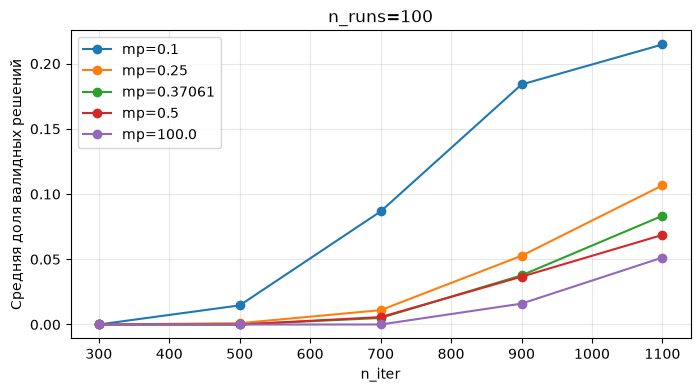

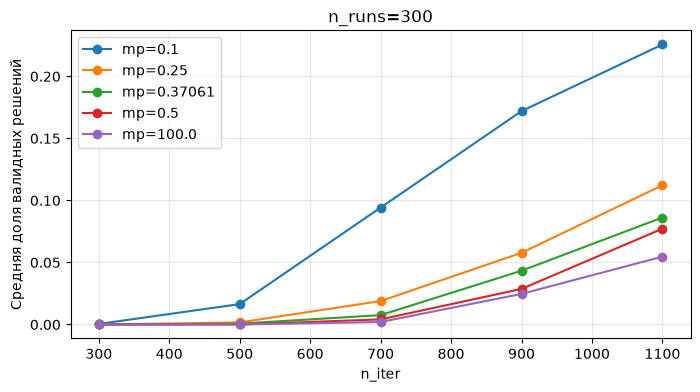

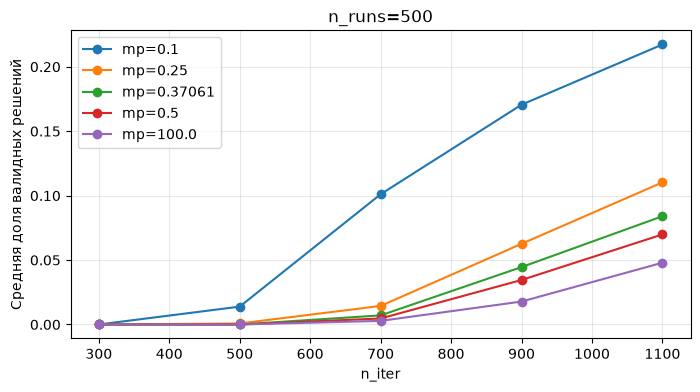

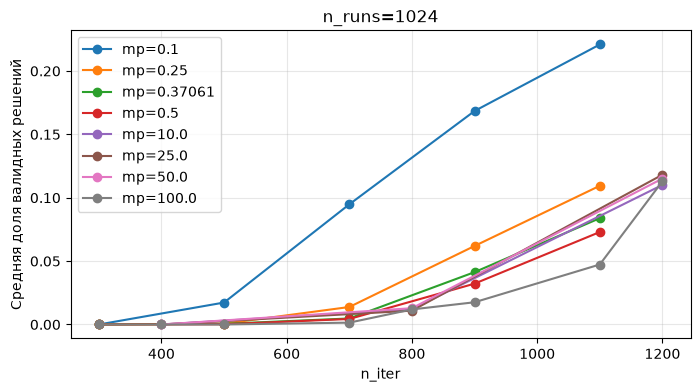

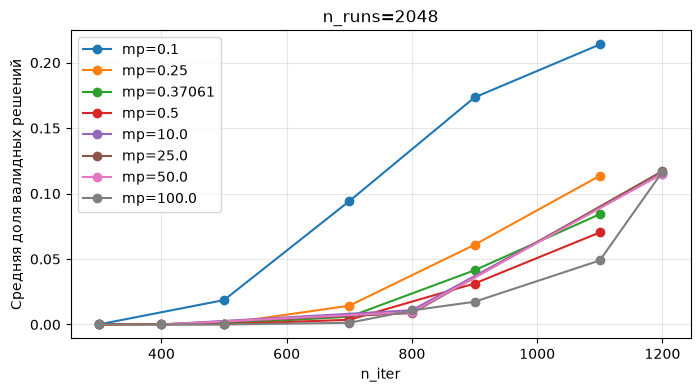

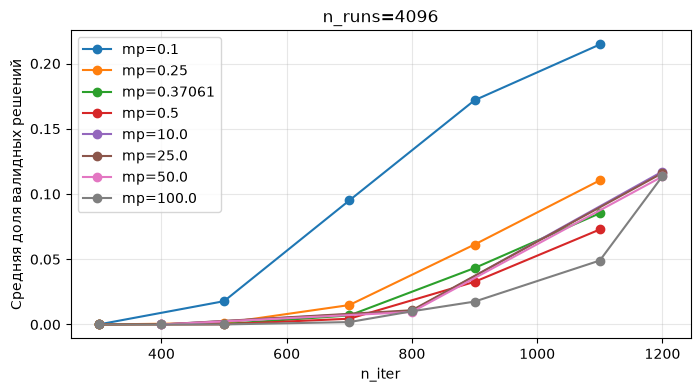

In [28]:
# Plot valid_rate vs parameters, grouped by n_runs.
if len(valid_df) > 0:
    for n_runs in sorted(valid_df['n_runs'].dropna().unique()):
        sub = valid_df[valid_df['n_runs'] == n_runs]
        plt.figure(figsize=(8, 4))
        for mp in sorted(sub['mp'].dropna().unique()):
            d = sub[sub['mp'] == mp].groupby('n_iter', as_index=False)['mean_valid_rate'].mean()
            plt.plot(d['n_iter'], d['mean_valid_rate'], marker='o', label=f'mp={mp}')
        plt.xlabel('n_iter')
        plt.ylabel('Средняя доля валидных решений')
        plt.title(f'n_runs={n_runs}')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

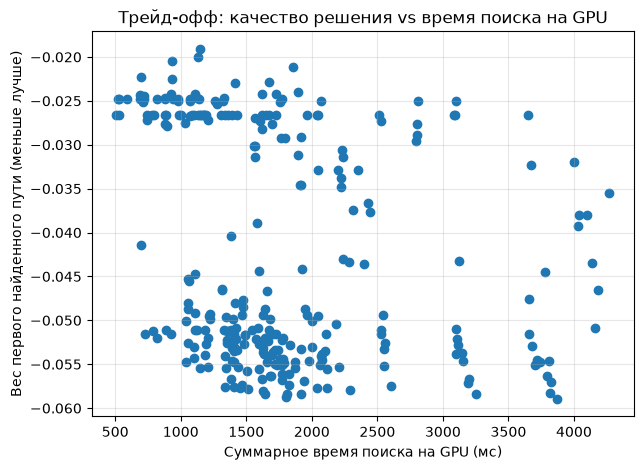

In [29]:
# Pareto-like view: quality vs time.
if len(valid_df) > 0 and 'first_path_weight' in valid_df.columns:
    q = valid_df[valid_df['n_pairs_found'] > 0].copy()
    if len(q) > 0:
        plt.figure(figsize=(7, 5))
        plt.scatter(q['sum_total_ms'], q['first_path_weight'])
        plt.xlabel('Суммарное время поиска на GPU (мс)')
        plt.ylabel('Вес первого найденного пути (меньше лучше)')
        plt.title('Трейд-офф: качество решения vs время поиска на GPU')
        plt.grid(True, alpha=0.3)
        plt.show()